# CCPO: Codebook Compression with Patched Outliers

Experimental notebook for the CCPO article. Runs a piecewise demonstration on a single layer of Qwen3-1.7B, showing that saliency-guided outlier patching significantly improves codebook compression quality.

**Sections:**
1. Setup & Config
2. Collect Activations
3. Energy Concentration
4. K-Means Codebook
5. Output Error Baseline
6. Patch Outliers
7. Patch Sweep
8. Tuning
9. Saliency Ablation
10. Patch Heatmap & Residuals
11. RLE Compression Study


## 0. Setup


In [ ]:
!pip install -q transformers datasets scikit-learn matplotlib torch


In [ ]:
%matplotlib inline

import torch
import torch.nn as nn
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


## 1. Config


In [ ]:
# ── Model ──────────────────────────────────────────────────────────────────────
MODEL_NAME = "Qwen/Qwen3-1.7B"
LAYER_INDEX = 14

# ── Codebook ───────────────────────────────────────────────────────────────────
CODE_SIZE = 8
NUM_CODES = 256

# ── Paths ──────────────────────────────────────────────────────────────────────
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)
ACTIVATIONS_PATH = os.path.join(RESULTS_DIR, "activations.pt")
CODEBOOK_PATH = os.path.join(RESULTS_DIR, "codebook.pt")
PATCHED_PATH = os.path.join(RESULTS_DIR, "patched.pt")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")


Device: cuda


## 2. Collect Activations

Load Qwen3-1.7B, run a subset of c4 through it, hook the `down_proj` layer to capture its input activations.


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset

NUM_ACTIVATIONS = 8192
SEQ_LEN = 2048
C4_STREAMING = True
DTYPE = torch.bfloat16

print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Loading model: {MODEL_NAME} ({DTYPE})")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=DTYPE,
    device_map=DEVICE,
)
model.eval()

# Identify target layer
target_layer = model.model.layers[LAYER_INDEX].mlp.down_proj
print(f"Target layer: model.layers[{LAYER_INDEX}].mlp.down_proj")
print(f"  Weight shape: {target_layer.weight.shape}")

# Save base weight matrix as float32
W = target_layer.weight.detach().float().cpu()
print(f"  Weight matrix: {W.shape} (saved as float32)")

# Register hook
collected_activations = []

def activation_hook(module, input, output):
    x = input[0].detach().float().cpu()
    x = x.reshape(-1, x.shape[-1])
    collected_activations.append(x)

hook_handle = target_layer.register_forward_hook(activation_hook)

# Load c4
print(f"Loading c4 dataset (streaming={C4_STREAMING})")
dataset = load_dataset("allenai/c4", "en", split="train", streaming=C4_STREAMING)

# Collect activations
print(f"Collecting {NUM_ACTIVATIONS} activation vectors...")
total_collected = 0

with torch.no_grad():
    for sample in dataset:
        if total_collected >= NUM_ACTIVATIONS:
            break

        tokens = tokenizer(
            sample["text"],
            return_tensors="pt",
            max_length=SEQ_LEN,
            truncation=True,
        )

        if tokens["input_ids"].shape[1] < 64:
            continue

        tokens = {k: v.to(DEVICE) for k, v in tokens.items()}
        model(**tokens)

        total_collected = sum(a.shape[0] for a in collected_activations)
        print(f"  Collected {total_collected}/{NUM_ACTIVATIONS} vectors", end="\r")

hook_handle.remove()

# Stack and trim
activations = torch.cat(collected_activations, dim=0)[:NUM_ACTIVATIONS]
print(f"\nFinal activation dataset: {activations.shape}")

# Save
metadata = {
    "model_name": MODEL_NAME,
    "layer_index": LAYER_INDEX,
    "layer_name": f"model.layers[{LAYER_INDEX}].mlp.down_proj",
    "weight_shape": list(W.shape),
    "num_activations": activations.shape[0],
    "activation_dim": activations.shape[1],
    "seq_len": SEQ_LEN,
    "dtype": str(DTYPE),
}

torch.save({"activations": activations, "weight": W, "metadata": metadata}, ACTIVATIONS_PATH)
print(f"Saved to {ACTIVATIONS_PATH}")

# Free model memory
del model, tokenizer, dataset, collected_activations
torch.cuda.empty_cache() if torch.cuda.is_available() else None
print("Model unloaded.")


Loading tokenizer: Qwen/Qwen3-1.7B


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading model: Qwen/Qwen3-1.7B (torch.bfloat16)


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Target layer: model.layers[14].mlp.down_proj
  Weight shape: torch.Size([2048, 6144])
  Weight matrix: torch.Size([2048, 6144]) (saved as float32)
Loading c4 dataset (streaming=True)


Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

  Collected 8368/8192 vectors
Final activation dataset: torch.Size([8192, 6144])
Saved to results/activations.pt
Model unloaded.


## 3. Energy Concentration

Compute and plot the energy concentration curve showing how much energy is captured by the top-k% of activation vector components.


Shape: torch.Size([8192, 6144]) (N=8192, d=6144)
  50% energy in top 1.29% of components (79/6144)
  80% energy in top 6.64% of components (408/6144)
  90% energy in top 14.26% of components (876/6144)
  95% energy in top 24.19% of components (1486/6144)
  99% energy in top 47.41% of components (2913/6144)


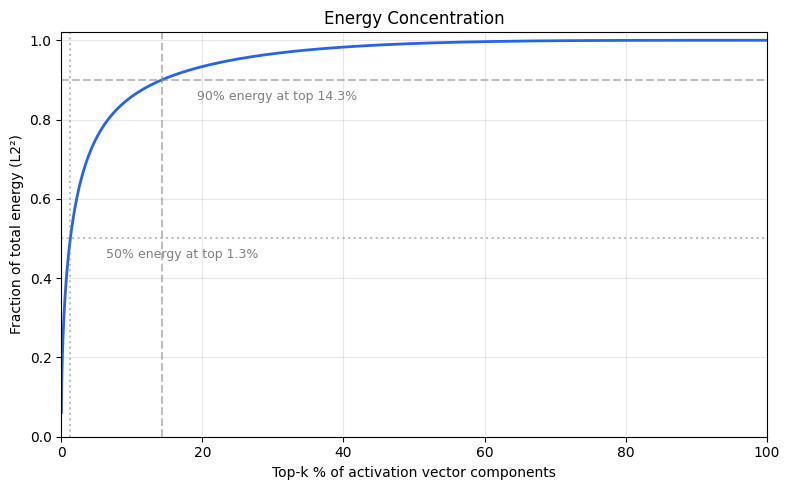

In [ ]:
data = torch.load(ACTIVATIONS_PATH, weights_only=False)
activations = data["activations"]
metadata = data["metadata"]

N, d = activations.shape
print(f"Shape: {activations.shape} (N={N}, d={d})")

# Compute energy concentration
squared = activations ** 2
total_energy = squared.sum(dim=1)
sorted_sq, _ = torch.sort(squared, dim=1, descending=True)
cumsum = torch.cumsum(sorted_sq, dim=1)
frac = cumsum / total_energy.unsqueeze(1)
mean_frac = frac.mean(dim=0).numpy()
k_pct = np.arange(1, d + 1) / d * 100

# Notable thresholds
for threshold in [0.5, 0.8, 0.9, 0.95, 0.99]:
    idx = np.searchsorted(mean_frac, threshold)
    pct = k_pct[idx] if idx < len(k_pct) else 100.0
    print(f"  {threshold * 100:.0f}% energy in top {pct:.2f}% of components ({idx + 1}/{d})")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_pct, mean_frac, color="#2563eb", linewidth=2)

for threshold, style in [(0.9, "--"), (0.5, ":")]:
    idx = np.searchsorted(mean_frac, threshold)
    pct = k_pct[idx] if idx < len(k_pct) else 100.0
    ax.axhline(y=threshold, color="gray", linestyle=style, alpha=0.5)
    ax.axvline(x=pct, color="gray", linestyle=style, alpha=0.5)
    ax.annotate(
        f"{threshold * 100:.0f}% energy at top {pct:.1f}%",
        xy=(pct, threshold), xytext=(pct + 5, threshold - 0.05),
        fontsize=9, color="gray",
    )

ax.set_xlabel("Top-k % of activation vector components")
ax.set_ylabel("Fraction of total energy (L2²)")
ax.set_title(f"Energy Concentration")
ax.set_xlim(0, 100); ax.set_ylim(0, 1.02); ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## 4. K-Means Codebook

Learn a codebook via mini-batch K-means, compress the weight matrix, and measure weight-space error.


In [ ]:
from sklearn.cluster import MiniBatchKMeans

KMEANS_BATCH_SIZE = 4096
KMEANS_MAX_ITER = 300
KMEANS_SEED = 42

data = torch.load(ACTIVATIONS_PATH, weights_only=False)
W = data["weight"]
metadata = data["metadata"]

out_features, in_features = W.shape
print(f"Weight shape: ({out_features}, {in_features})")
assert in_features % CODE_SIZE == 0

num_groups_per_row = in_features // CODE_SIZE
num_groups_total = out_features * num_groups_per_row
training_data = W.reshape(num_groups_total, CODE_SIZE).numpy()
print(f"Training set: {training_data.shape} ({num_groups_total} groups of {CODE_SIZE})")

print(f"Running MiniBatchKMeans (n_clusters={NUM_CODES}, max_iter={KMEANS_MAX_ITER})...")
kmeans = MiniBatchKMeans(
    n_clusters=NUM_CODES, batch_size=KMEANS_BATCH_SIZE,
    max_iter=KMEANS_MAX_ITER, random_state=KMEANS_SEED,
    init="k-means++", verbose=1,
)
kmeans.fit(training_data)
print(f"Converged. Inertia: {kmeans.inertia_:.6f}")

codebook = torch.from_numpy(kmeans.cluster_centers_).float()
indices = torch.from_numpy(kmeans.labels_).long()
W_hat = codebook[indices].reshape(out_features, in_features)

print(f"Codebook: {codebook.shape}")
print(f"Indices:  {indices.shape}")

# Weight-space error
diff = W - W_hat
frob_error = torch.norm(diff, p="fro") / torch.norm(W, p="fro")
abs_diff = diff.abs()
p99_error = torch.quantile(abs_diff.flatten(), 0.99)

print(f"\nWeight-space error:")
print(f"  Relative Frobenius Error: {frob_error:.6f}")
print(f"  P99 Absolute Error:       {p99_error:.6f}")
print(f"  Max Absolute Error:        {abs_diff.max():.6f}")
print(f"  Mean Absolute Error:       {abs_diff.mean():.6f}")

# Compression stats
original_bits = out_features * in_features * 32
compressed_bits = num_groups_total * 8 + NUM_CODES * CODE_SIZE * 32
print(f"\nCompression:")
print(f"  Ratio:      {original_bits / compressed_bits:.2f}x")
print(f"  Effective bits-per-weight: {compressed_bits / (out_features * in_features):.2f}")

torch.save({
    "codebook": codebook, "indices": indices, "W_hat": W_hat,
    "metrics": {"relative_frob_error": frob_error.item(), "p99_abs_error": p99_error.item(),
                "max_abs_error": abs_diff.max().item(), "mean_abs_error": abs_diff.mean().item(),
                "inertia": kmeans.inertia_, "effective_bpw": compressed_bits / (out_features * in_features)},
    "config": {"code_size": CODE_SIZE, "num_codes": NUM_CODES, "num_groups_per_row": num_groups_per_row,
               "num_groups_total": num_groups_total},
    "metadata": metadata,
}, CODEBOOK_PATH)
print(f"Saved to {CODEBOOK_PATH}")


Weight shape: (2048, 6144)
Training set: (1572864, 8) (1572864 groups of 8)
Running MiniBatchKMeans (n_clusters=256, max_iter=300)...
Init 1/1 with method k-means++
Inertia for init 1/1: 36.541160583496094
Minibatch step 1/115200: mean batch inertia: 0.0029979143291711807
Minibatch step 2/115200: mean batch inertia: 0.0029136750381439924, ewa inertia: 0.0029136750381439924
Minibatch step 3/115200: mean batch inertia: 0.0028505863156169653, ewa inertia: 0.0029133464512564075
Minibatch step 4/115200: mean batch inertia: 0.0029393224976956844, ewa inertia: 0.002913481743078929
Minibatch step 5/115200: mean batch inertia: 0.00284212501719594, ewa inertia: 0.0029131100937012434
Minibatch step 6/115200: mean batch inertia: 0.0028702649287879467, ewa inertia: 0.002912886941942529
Minibatch step 7/115200: mean batch inertia: 0.0028809718787670135, ewa inertia: 0.002912720717760839
Minibatch step 8/115200: mean batch inertia: 0.002858899300917983, ewa inertia: 0.0029124403980596717
Minibatch st

## 5. Output Error Baseline

Compute output-space error metrics (NMSE and cosine similarity) for the codebook-only compression.


In [ ]:
act_data = torch.load(ACTIVATIONS_PATH, weights_only=False)
cb_data = torch.load(CODEBOOK_PATH, weights_only=False)

X = act_data["activations"]
W = act_data["weight"]
W_hat = cb_data["W_hat"]

print(f"Activations: {X.shape}")
print(f"W: {W.shape}, W_hat: {W_hat.shape}")

Y = X @ W.T
Y_hat = X @ W_hat.T

# NMSE
nmse = (Y - Y_hat).pow(2).sum() / Y.pow(2).sum()

# Cosine similarity
cos_sim = ((Y * Y_hat).sum(dim=1) / (Y.norm(dim=1) * Y_hat.norm(dim=1))).mean()

print(f"\nOutput-space error (codebook only, no patching):")
print(f"  NMSE:              {nmse:.6f}")
print(f"  Cosine Similarity: {cos_sim:.6f}")


Activations: torch.Size([8192, 6144])
W: torch.Size([2048, 6144]), W_hat: torch.Size([2048, 6144])

Output-space error (codebook only, no patching):
  NMSE:              0.393245
  Cosine Similarity: 0.780341


## 6. Patch Outliers

Compute saliency, select top-k% outliers, patch them, and measure improvement.


In [ ]:
PATCH_BUDGET = 0.01

act_data = torch.load(ACTIVATIONS_PATH, weights_only=False)
cb_data = torch.load(CODEBOOK_PATH, weights_only=False)

X = act_data["activations"]
W = act_data["weight"]
W_hat = cb_data["W_hat"]

out_features, in_features = W.shape
num_weights = out_features * in_features
num_patches = int(num_weights * PATCH_BUDGET)

print(f"Patch budget: {PATCH_BUDGET * 100:.1f}% = {num_patches} weights")

# Saliency
diff = (W - W_hat).abs()
rms_x = X.pow(2).mean(dim=0).sqrt()
S = diff * rms_x.unsqueeze(0)

# Select and patch
S_flat = S.flatten()
_, topk_flat_indices = torch.topk(S_flat, num_patches)
rows = topk_flat_indices // in_features
cols = topk_flat_indices % in_features

W_patched = W_hat.clone()
for i in range(num_patches):
    r, c = rows[i].item(), cols[i].item()
    W_patched[r, c] = W[r, c]

# Output error
Y = X @ W.T
Y_hat = X @ W_hat.T
Y_patched = X @ W_patched.T

nmse_codebook = (Y - Y_hat).pow(2).sum() / Y.pow(2).sum()
nmse_patched = (Y - Y_patched).pow(2).sum() / Y.pow(2).sum()
cos_codebook = ((Y * Y_hat).sum(dim=1) / (Y.norm(dim=1) * Y_hat.norm(dim=1))).mean()
cos_patched = ((Y * Y_patched).sum(dim=1) / (Y.norm(dim=1) * Y_patched.norm(dim=1))).mean()

print(f"\nResults (patch budget = {PATCH_BUDGET * 100:.1f}%):")
print(f"  {'Metric':<22} {'Codebook':>12} {'Patched':>12} {'Improvement':>12}")
print(f"  {'-'*58}")
print(f"  {'NMSE':<22} {nmse_codebook:.6f}     {nmse_patched:.6f}     {(1 - nmse_patched / nmse_codebook) * 100:.1f}%")
print(f"  {'Cosine Similarity':<22} {cos_codebook:.6f}     {cos_patched:.6f}     {(cos_patched - cos_codebook) * 100:.4f}pp")

torch.save({
    "W_patched": W_patched, "saliency": S,
    "patch_indices_rows": rows, "patch_indices_cols": cols,
    "patch_budget": PATCH_BUDGET, "num_patches": num_patches,
    "metrics": {"nmse_codebook": nmse_codebook.item(), "nmse_patched": nmse_patched.item(),
                "cos_codebook": cos_codebook.item(), "cos_patched": cos_patched.item()},
    "metadata": act_data["metadata"],
}, PATCHED_PATH)
print(f"Saved to {PATCHED_PATH}")


Patch budget: 1.0% = 125829 weights

Results (patch budget = 1.0%):
  Metric                     Codebook      Patched  Improvement
  ----------------------------------------------------------
  NMSE                   0.393245     0.293554     25.4%
  Cosine Similarity      0.780341     0.841779     6.1437pp
Saved to results/patched.pt


## 7. Patch Budget Sweep

Sweep patching budget from 0% to 100% and plot NMSE/cosine vs budget.


Loading data...
  W shape: (2048, 6144)
  Total weights: 12582912
Precomputing...
Sweeping 38 budget values...
  Budget    0.0%: NMSE=0.393245  Cosine=0.780341  RelFrob=0.579722  P99Err=0.051182
  Budget    0.1%: NMSE=0.352597  Cosine=0.806528  RelFrob=0.577096  P99Err=0.051006
  Budget    0.2%: NMSE=0.340720  Cosine=0.813652  RelFrob=0.575608  P99Err=0.050872
  Budget    0.3%: NMSE=0.332088  Cosine=0.818878  RelFrob=0.574203  P99Err=0.050734
  Budget    0.4%: NMSE=0.324721  Cosine=0.823308  RelFrob=0.572856  P99Err=0.050623
  Budget    0.5%: NMSE=0.318200  Cosine=0.827215  RelFrob=0.571553  P99Err=0.050505
  Budget    0.6%: NMSE=0.312516  Cosine=0.830594  RelFrob=0.570244  P99Err=0.050384
  Budget    0.7%: NMSE=0.307327  Cosine=0.833669  RelFrob=0.568970  P99Err=0.050266
  Budget    0.8%: NMSE=0.302529  Cosine=0.836493  RelFrob=0.567691  P99Err=0.050150
  Budget    0.9%: NMSE=0.297933  Cosine=0.839195  RelFrob=0.566425  P99Err=0.050043
  Budget    1.0%: NMSE=0.293554  Cosine=0.841779 

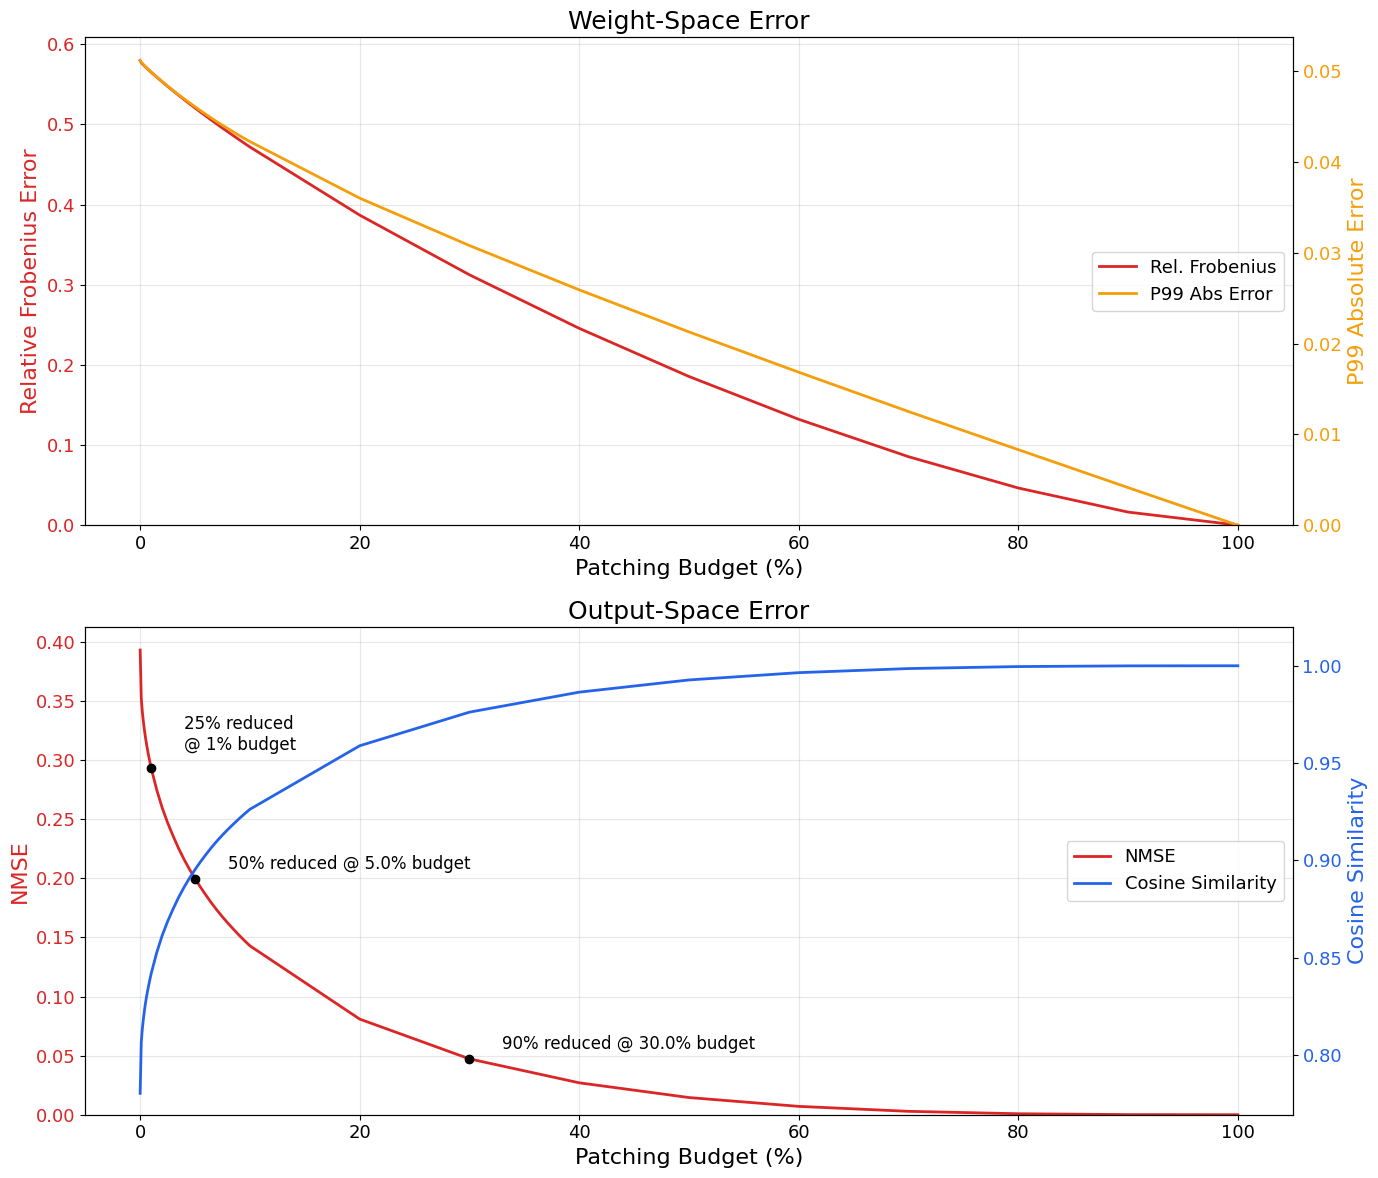

In [ ]:
"""
06_patch_sweep.py

Sweeps patching budget from 0% to 100%, measuring output-space error at each
point. Produces a plot showing NMSE and cosine similarity vs patching budget.
"""

import torch
import numpy as np
import os
import matplotlib.pyplot as plt
#from config import RESULTS_DIR, ACTIVATIONS_PATH, CODEBOOK_PATH

# ── Constants ──────────────────────────────────────────────────────────────────
BUDGETS = np.concatenate([
    np.arange(0, 1, 0.1),      # 0.0% to 0.9% in 0.1% steps
    np.arange(1, 10, 0.5),     # 1% to 9.5% in 0.5% steps
    np.arange(10, 101, 10),    # 10% to 100% in 10% steps
]) / 100  # Convert to fractions

# ── Load data ──────────────────────────────────────────────────────────────────
print("Loading data...")
act_data = torch.load(ACTIVATIONS_PATH, weights_only=False)
cb_data = torch.load(CODEBOOK_PATH, weights_only=False)

X = act_data["activations"]    # (N, d)
W = act_data["weight"]         # (out_features, in_features)
W_hat = cb_data["W_hat"]       # (out_features, in_features)
metadata = act_data["metadata"]

out_features, in_features = W.shape
num_weights = out_features * in_features

print(f"  W shape: ({out_features}, {in_features})")
print(f"  Total weights: {num_weights}")

# ── Precompute base output and saliency ────────────────────────────────────────
print("Precomputing...")

Y = X @ W.T  # (N, out_features)
Y_norm_sq = Y.pow(2).sum()
Y_norms = Y.norm(dim=1)

# Saliency
diff = (W - W_hat).abs()
rms_x = X.pow(2).mean(dim=0).sqrt()
S = diff * rms_x.unsqueeze(0)

# Sort all weights by saliency descending (once)
S_flat = S.flatten()
_, sorted_indices = torch.sort(S_flat, descending=True)

rows = sorted_indices // in_features
cols = sorted_indices % in_features

# ── Sweep ──────────────────────────────────────────────────────────────────────
print(f"Sweeping {len(BUDGETS)} budget values...")

nmse_values = []
cos_values = []
frob_values = []
max_err_values = []

W_frob = torch.norm(W, p="fro")

# Track W_patched incrementally (no clone per budget)
W_patched = W_hat.clone()
remaining_errors = (W - W_hat).abs().flatten().clone()
frob_sq = (W - W_hat).pow(2).sum().item()

prev_num_patches = 0

for budget in BUDGETS:
    num_patches = int(num_weights * budget)

    # Apply only new patches since last budget
    if num_patches > prev_num_patches:
        new_rows = rows[prev_num_patches:num_patches]
        new_cols = cols[prev_num_patches:num_patches]

        # Update Frobenius tracking
        frob_sq -= (W[new_rows, new_cols] - W_hat[new_rows, new_cols]).pow(2).sum().item()

        # Zero out patched entries for P99
        flat_idx = new_rows * in_features + new_cols
        remaining_errors[flat_idx] = 0

        # Apply patches
        W_patched[new_rows, new_cols] = W[new_rows, new_cols]

    prev_num_patches = num_patches

    # Weight-space metrics
    rel_frob = max(0, frob_sq) ** 0.5 / W_frob.item()
    if num_patches < num_weights:
        active = remaining_errors[remaining_errors > 0]
        max_abs = torch.quantile(active, 0.99).item() if len(active) > 0 else 0.0
    else:
        max_abs = 0.0

    frob_values.append(rel_frob)
    max_err_values.append(max_abs)

    # Output-space metrics
    Y_patched = X @ W_patched.T

    nmse = (Y - Y_patched).pow(2).sum() / Y_norm_sq
    cos = (
        (Y * Y_patched).sum(dim=1) / (Y_norms * Y_patched.norm(dim=1))
    ).mean()

    nmse_values.append(nmse.item())
    cos_values.append(cos.item())

    print(f"  Budget {budget * 100:6.1f}%: NMSE={nmse:.6f}  Cosine={cos:.6f}  "
          f"RelFrob={rel_frob:.6f}  P99Err={max_abs:.6f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
print("Plotting...")

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
})

budgets_pct = BUDGETS * 100

fig, (ax_w, ax_o) = plt.subplots(2, 1, figsize=(14, 12))

# Left: weight-space metrics
color_frob = "#dc2626"
ax_w.plot(budgets_pct, frob_values, color=color_frob, linewidth=2, label="Rel. Frobenius")
ax_w.set_xlabel("Patching Budget (%)")
ax_w.set_ylabel("Relative Frobenius Error", color=color_frob)
ax_w.tick_params(axis="y", labelcolor=color_frob)
ax_w.set_ylim(bottom=0)

ax_w2 = ax_w.twinx()
color_max = "#f59e0b"
ax_w2.plot(budgets_pct, max_err_values, color=color_max, linewidth=2, label="P99 Abs Error")
ax_w2.set_ylabel("P99 Absolute Error", color=color_max)
ax_w2.tick_params(axis="y", labelcolor=color_max)
ax_w2.set_ylim(bottom=0)

lines_w1, labels_w1 = ax_w.get_legend_handles_labels()
lines_w2, labels_w2 = ax_w2.get_legend_handles_labels()
ax_w.legend(lines_w1 + lines_w2, labels_w1 + labels_w2, loc="center right")
ax_w.set_title("Weight-Space Error")
ax_w.grid(True, alpha=0.3)

# Right: output-space metrics
color_nmse = "#dc2626"
ax_o.plot(budgets_pct, nmse_values, color=color_nmse, linewidth=2, label="NMSE")
ax_o.set_xlabel("Patching Budget (%)")
ax_o.set_ylabel("NMSE", color=color_nmse)
ax_o.tick_params(axis="y", labelcolor=color_nmse)
ax_o.set_ylim(bottom=0)

ax_o2 = ax_o.twinx()
color_cos = "#2563eb"
ax_o2.plot(budgets_pct, cos_values, color=color_cos, linewidth=2, label="Cosine Similarity")
ax_o2.set_ylabel("Cosine Similarity", color=color_cos)
ax_o2.tick_params(axis="y", labelcolor=color_cos)
ax_o2.set_ylim(top=1.02)

# Milestone markers on NMSE curve
nmse_arr = np.array(nmse_values)
budgets_arr = np.array(budgets_pct)
nmse_0 = nmse_arr[0]

# 1% budget
idx_1pct = np.argmin(np.abs(budgets_arr - 1.0))
reduction_1pct = (1 - nmse_arr[idx_1pct] / nmse_0) * 100

# 50% and 90% error reduction
idx_50 = np.argmin(np.abs(nmse_arr - nmse_0 * 0.5))
idx_90 = np.argmin(np.abs(nmse_arr - nmse_0 * 0.1))

markers = [
    (budgets_arr[idx_1pct], nmse_arr[idx_1pct], f"{reduction_1pct:.0f}% reduced\n@ 1% budget", (3, 0.015)),
    (budgets_arr[idx_50],   nmse_arr[idx_50],   f"50% reduced @ {budgets_arr[idx_50]:.1f}% budget", (3, 0.008)),
    (budgets_arr[idx_90],   nmse_arr[idx_90],   f"90% reduced @ {budgets_arr[idx_90]:.1f}% budget", (3, 0.008)),
]

for bx, ny, label, (dx, dy) in markers:
    ax_o.plot(bx, ny, "ko", markersize=6, zorder=5)
    ax_o.annotate(label, xy=(bx, ny), xytext=(bx + dx, ny + dy),
                  fontsize=12, color="black")

lines_o1, labels_o1 = ax_o.get_legend_handles_labels()
lines_o2, labels_o2 = ax_o2.get_legend_handles_labels()
ax_o.legend(lines_o1 + lines_o2, labels_o1 + labels_o2, loc="center right")
ax_o.set_title("Output-Space Error")
ax_o.grid(True, alpha=0.3)

#fig.suptitle(f"Patch Sweep — {metadata['model_name']} layer {metadata['layer_index']} down_proj", fontsize=20)
fig.tight_layout()

plot_path = os.path.join(RESULTS_DIR, "patch_sweep.png")
fig.savefig(plot_path, dpi=200, bbox_inches="tight")
print(f"Saved plot to {plot_path}")

# ── Save data ─────────────────────────────────────────────────────────────────
data_path = os.path.join(RESULTS_DIR, "patch_sweep.pt")
torch.save(
    {
        "budgets": BUDGETS,
        "nmse": nmse_values,
        "cosine_similarity": cos_values,
        "rel_frobenius": frob_values,
        "p99_abs_error": max_err_values,
        "metadata": metadata,
    },
    data_path,
)

print(f"Saved data to {data_path}")
print("Done.")

## 8. Tuning

Tune codebook codes and/or patch values via gradient descent on output MSE.


Loading data...
  W shape: (2048, 6144)
  Codebook: torch.Size([256, 8])
  Patches: 125829

Mode: code_only
  Before tuning: NMSE=0.293554  Cosine=0.841779
  Step    1: loss=6265559.0000  NMSE=0.293554  Cosine=0.841779
  Step   50: loss=6187309.0000  NMSE=0.289888  Cosine=0.842722
  Step  100: loss=6187164.5000  NMSE=0.289881  Cosine=0.842725
  Step  150: loss=6187164.0000  NMSE=0.289881  Cosine=0.842725
  Step  200: loss=6187164.0000  NMSE=0.289881  Cosine=0.842725
  Step  250: loss=6187164.0000  NMSE=0.289881  Cosine=0.842725
  Step  300: loss=6187164.0000  NMSE=0.289881  Cosine=0.842725
  Step  350: loss=6187164.0000  NMSE=0.289881  Cosine=0.842725
  Step  400: loss=6187164.0000  NMSE=0.289881  Cosine=0.842725
  Step  450: loss=6187164.0000  NMSE=0.289881  Cosine=0.842725
  Step  500: loss=6187164.0000  NMSE=0.289881  Cosine=0.842725
  After tuning:  NMSE=0.289881  Cosine=0.842725

Mode: patch_only
  Before tuning: NMSE=0.293554  Cosine=0.841779
  Step    1: loss=6265559.0000  NMSE=

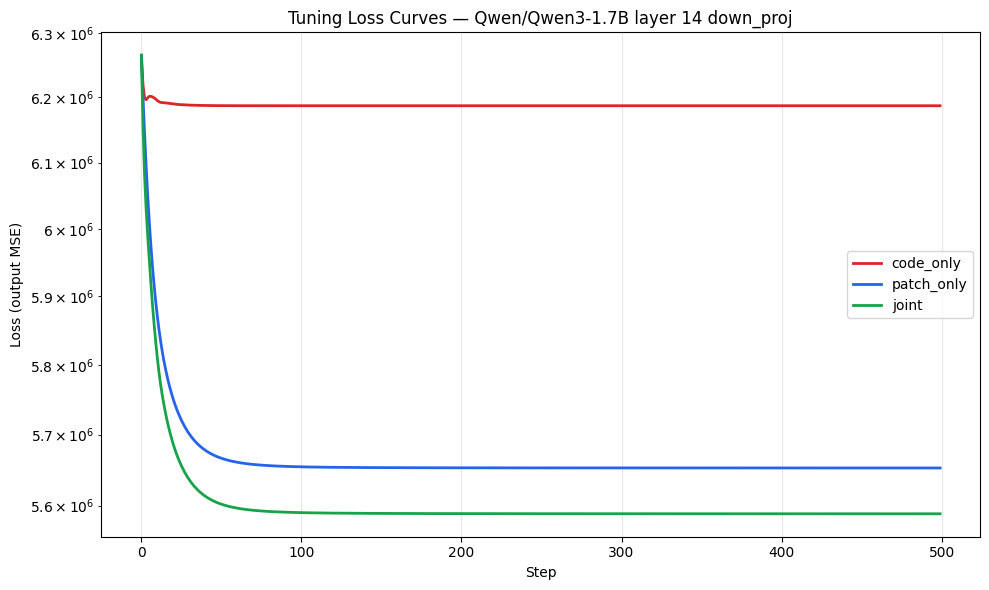

In [ ]:
"""
07_tuning.py

Tunes codebook codes and/or patch values to minimize output reconstruction
error. Three independent modes:
  1. Code tuning only (no patches)
  2. Patch value tuning only (codebook fixed)
  3. Joint tuning (codes + patch values)
"""

import torch
import torch.nn as nn
import os
import matplotlib.pyplot as plt
#from config import RESULTS_DIR, ACTIVATIONS_PATH, CODEBOOK_PATH, PATCHED_PATH

# ── Constants ──────────────────────────────────────────────────────────────────
LR = 1e-3
NUM_STEPS = 500
LOG_EVERY = 50
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ── Load data ──────────────────────────────────────────────────────────────────
print("Loading data...")
act_data = torch.load(ACTIVATIONS_PATH, weights_only=False)
cb_data = torch.load(CODEBOOK_PATH, weights_only=False)
patch_data = torch.load(PATCHED_PATH, weights_only=False)

X = act_data["activations"].to(DEVICE)           # (N, d)
W = act_data["weight"].to(DEVICE)                 # (out_features, in_features)
codebook_init = cb_data["codebook"].to(DEVICE)    # (NUM_CODES, CODE_SIZE)
indices = cb_data["indices"].to(DEVICE)           # (num_groups_total,)
patch_rows = patch_data["patch_indices_rows"].to(DEVICE)
patch_cols = patch_data["patch_indices_cols"].to(DEVICE)

out_features, in_features = W.shape
metadata = act_data["metadata"]

# Precompute target output
Y = X @ W.T  # (N, out_features)

# Precompute patch mask
mask = torch.zeros_like(W)
mask[patch_rows, patch_cols] = 1.0

# Initial patch values (original weight values at patch positions)
patch_values_init = W[patch_rows, patch_cols].clone()

print(f"  W shape: ({out_features}, {in_features})")
print(f"  Codebook: {codebook_init.shape}")
print(f"  Patches: {patch_rows.shape[0]}")


def compute_metrics(W_approx):
    """Compute NMSE and cosine similarity."""
    Y_approx = X @ W_approx.T
    nmse = (Y - Y_approx).pow(2).sum() / Y.pow(2).sum()
    cos = (
        (Y * Y_approx).sum(dim=1) / (Y.norm(dim=1) * Y_approx.norm(dim=1))
    ).mean()
    return nmse.item(), cos.item()


def reconstruct(codebook, patch_values=None):
    """Build W_approx from codebook + optional patches."""
    W_hat = codebook[indices].reshape(out_features, in_features)

    if patch_values is not None:
        patch_dense = torch.zeros_like(W)
        patch_dense[patch_rows, patch_cols] = patch_values
        W_hat = W_hat * (1 - mask) + patch_dense * mask

    return W_hat


def run_tuning(mode):
    """
    Run a tuning loop.
    mode: 'code_only', 'patch_only', 'joint'
    """
    print(f"\n{'='*60}")
    print(f"Mode: {mode}")
    print(f"{'='*60}")

    # Set up parameters
    codebook = codebook_init.clone()
    patch_values = patch_values_init.clone()

    params = []

    if mode in ("code_only", "joint"):
        codebook = nn.Parameter(codebook)
        params.append(codebook)

    if mode in ("patch_only", "joint"):
        patch_values = nn.Parameter(patch_values)
        params.append(patch_values)

    use_patches = mode in ("patch_only", "joint")

    # All modes start from codebook + patches (same starting state).
    # code_only: patches present but frozen, only codebook tunes.
    # patch_only: codebook frozen, only patches tune.
    # joint: both tune.

    # Baseline before tuning
    with torch.no_grad():
        W_approx = reconstruct(codebook, patch_values)
        nmse_before, cos_before = compute_metrics(W_approx)
    print(f"  Before tuning: NMSE={nmse_before:.6f}  Cosine={cos_before:.6f}")

    # Optimizer
    optimizer = torch.optim.Adam(params, lr=LR)

    # Training loop
    loss_history = []

    for step in range(NUM_STEPS):
        optimizer.zero_grad()

        W_approx = reconstruct(codebook, patch_values)
        Y_approx = X @ W_approx.T

        loss = (Y - Y_approx).pow(2).sum()
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        if (step + 1) % LOG_EVERY == 0 or step == 0:
            with torch.no_grad():
                nmse, cos = compute_metrics(W_approx)
            print(f"  Step {step+1:4d}: loss={loss.item():.4f}  NMSE={nmse:.6f}  Cosine={cos:.6f}")

    # Final metrics
    with torch.no_grad():
        W_approx = reconstruct(codebook, patch_values)
        nmse_after, cos_after = compute_metrics(W_approx)
    print(f"  After tuning:  NMSE={nmse_after:.6f}  Cosine={cos_after:.6f}")

    return {
        "mode": mode,
        "nmse_before": nmse_before,
        "nmse_after": nmse_after,
        "cos_before": cos_before,
        "cos_after": cos_after,
        "loss_history": loss_history,
        "codebook": codebook.detach().cpu() if isinstance(codebook, nn.Parameter) else codebook.cpu(),
        "patch_values": patch_values.detach().cpu() if isinstance(patch_values, nn.Parameter) else patch_values.cpu(),
    }


# ── Run all three modes ───────────────────────────────────────────────────────
results = {}
for mode in ["code_only", "patch_only", "joint"]:
    results[mode] = run_tuning(mode)

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("Summary")
print(f"{'='*60}")
print(f"  {'Mode':<14} {'NMSE before':>12} {'NMSE after':>12} {'Cosine before':>14} {'Cosine after':>14}")
print(f"  {'-'*66}")
for mode, r in results.items():
    print(f"  {mode:<14} {r['nmse_before']:>12.6f} {r['nmse_after']:>12.6f} {r['cos_before']:>14.6f} {r['cos_after']:>14.6f}")

# ── Plot loss curves ──────────────────────────────────────────────────────────
print("\nPlotting...")

fig, ax = plt.subplots(figsize=(10, 6))
colors = {"code_only": "#dc2626", "patch_only": "#2563eb", "joint": "#16a34a"}

for mode, r in results.items():
    ax.plot(r["loss_history"], color=colors[mode], linewidth=2, label=mode)

ax.set_xlabel("Step")
ax.set_ylabel("Loss (output MSE)")
ax.set_title(f"Tuning Loss Curves — {metadata['model_name']} layer {metadata['layer_index']} down_proj")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_yscale("log")

fig.tight_layout()

plot_path = os.path.join(RESULTS_DIR, "tuning_loss.png")
fig.savefig(plot_path, dpi=150)
print(f"Saved plot to {plot_path}")

# ── Save ──────────────────────────────────────────────────────────────────────
save_path = os.path.join(RESULTS_DIR, "tuning.pt")
torch.save(
    {
        "results": {mode: {k: v for k, v in r.items() if k != "loss_history"}
                    for mode, r in results.items()},
        "loss_histories": {mode: r["loss_history"] for mode, r in results.items()},
        "config": {
            "lr": LR,
            "num_steps": NUM_STEPS,
        },
        "metadata": metadata,
    },
    save_path,
)

print(f"Saved to {save_path}")
print("Done.")

## 9. Saliency Ablation

Compare different outlier selection strategies: combined, reconstruction-only, activation-only, and random.


  Budget    0.0%: combined=0.3932  recon_only=0.3932  act_only=0.3932  random=0.3932
  Budget    0.1%: combined=0.3526  recon_only=0.3687  act_only=0.3796  random=0.3929
  Budget    0.2%: combined=0.3407  recon_only=0.3654  act_only=0.3710  random=0.3925
  Budget    0.3%: combined=0.3321  recon_only=0.3626  act_only=0.3656  random=0.3921
  Budget    0.4%: combined=0.3247  recon_only=0.3599  act_only=0.3608  random=0.3917
  Budget    0.5%: combined=0.3182  recon_only=0.3574  act_only=0.3564  random=0.3913
  Budget    0.6%: combined=0.3125  recon_only=0.3548  act_only=0.3521  random=0.3909
  Budget    0.7%: combined=0.3073  recon_only=0.3525  act_only=0.3476  random=0.3906
  Budget    0.8%: combined=0.3025  recon_only=0.3501  act_only=0.3437  random=0.3902
  Budget    0.9%: combined=0.2979  recon_only=0.3479  act_only=0.3400  random=0.3899
  Budget    1.0%: combined=0.2936  recon_only=0.3459  act_only=0.3372  random=0.3895
  Budget    1.5%: combined=0.2753  recon_only=0.3356  act_only=0.

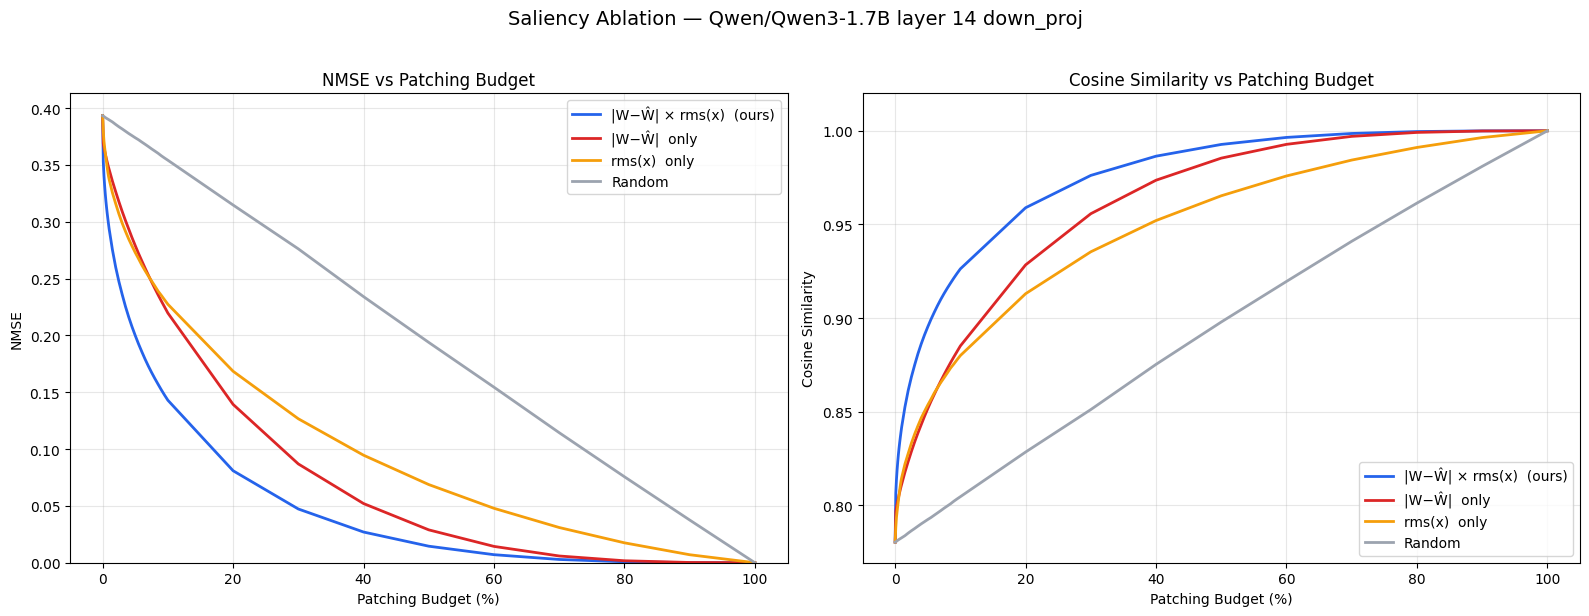

In [ ]:
BUDGETS = np.concatenate([
    np.arange(0, 1, 0.1), np.arange(1, 10, 0.5), np.arange(10, 101, 10),
]) / 100
RANDOM_SEED = 42

act_data = torch.load(ACTIVATIONS_PATH, weights_only=False)
cb_data = torch.load(CODEBOOK_PATH, weights_only=False)

X = act_data["activations"]; W = act_data["weight"]; W_hat = cb_data["W_hat"]
metadata = act_data["metadata"]
out_features, in_features = W.shape
num_weights = out_features * in_features

Y = X @ W.T; Y_norm_sq = Y.pow(2).sum(); Y_norms = Y.norm(dim=1)
diff = (W - W_hat).abs(); rms_x = X.pow(2).mean(dim=0).sqrt()

strategies = {}
_, idx = torch.sort((diff * rms_x.unsqueeze(0)).flatten(), descending=True); strategies["combined"] = idx
_, idx = torch.sort(diff.flatten(), descending=True); strategies["recon_only"] = idx
_, idx = torch.sort(rms_x.unsqueeze(0).expand(out_features, in_features).flatten(), descending=True); strategies["act_only"] = idx
strategies["random"] = torch.randperm(num_weights, generator=torch.Generator().manual_seed(RANDOM_SEED))

results = {name: {"nmse": [], "cos": []} for name in strategies}

for budget in BUDGETS:
    num_patches = int(num_weights * budget)
    for name, sorted_indices in strategies.items():
        W_patched = W_hat.clone()
        if num_patches > 0:
            patch_flat = sorted_indices[:num_patches]
            r, c = patch_flat // in_features, patch_flat % in_features
            W_patched[r, c] = W[r, c]
        Y_patched = X @ W_patched.T
        results[name]["nmse"].append(((Y - Y_patched).pow(2).sum() / Y_norm_sq).item())
        results[name]["cos"].append(((Y * Y_patched).sum(dim=1) / (Y_norms * Y_patched.norm(dim=1))).mean().item())
    print(f"  Budget {budget*100:6.1f}%: " + "  ".join(f"{n}={results[n]['nmse'][-1]:.4f}" for n in strategies))

# Plot
budgets_pct = BUDGETS * 100
colors = {"combined": "#2563eb", "recon_only": "#dc2626", "act_only": "#f59e0b", "random": "#9ca3af"}
labels = {"combined": "|W−Ŵ| × rms(x)  (ours)", "recon_only": "|W−Ŵ|  only", "act_only": "rms(x)  only", "random": "Random"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for name in strategies:
    ax1.plot(budgets_pct, results[name]["nmse"], color=colors[name], linewidth=2, label=labels[name])
ax1.set_xlabel("Patching Budget (%)"); ax1.set_ylabel("NMSE"); ax1.set_title("NMSE vs Patching Budget")
ax1.legend(); ax1.grid(True, alpha=0.3); ax1.set_ylim(bottom=0)

for name in strategies:
    ax2.plot(budgets_pct, results[name]["cos"], color=colors[name], linewidth=2, label=labels[name])
ax2.set_xlabel("Patching Budget (%)"); ax2.set_ylabel("Cosine Similarity"); ax2.set_title("Cosine Similarity vs Patching Budget")
ax2.legend(); ax2.grid(True, alpha=0.3); ax2.set_ylim(top=1.02)

fig.suptitle(f"Saliency Ablation — {metadata['model_name']} layer {metadata['layer_index']} down_proj", fontsize=14, y=1.02)
fig.tight_layout(); plt.show()


## 10. Patch Heatmap & Residual Analysis

Visualize patch locations, column/row marginals, group coverage, and residual distribution.


Group coverage:
  Total groups:         1572864
  Groups with ≥1 patch: 120640 (7.67%)
  Avg patches/group:    1.04
  Correlation(col_patch_count, rms_x): 0.8326


/tmp/ipython-input-4114153725.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); plt.show()


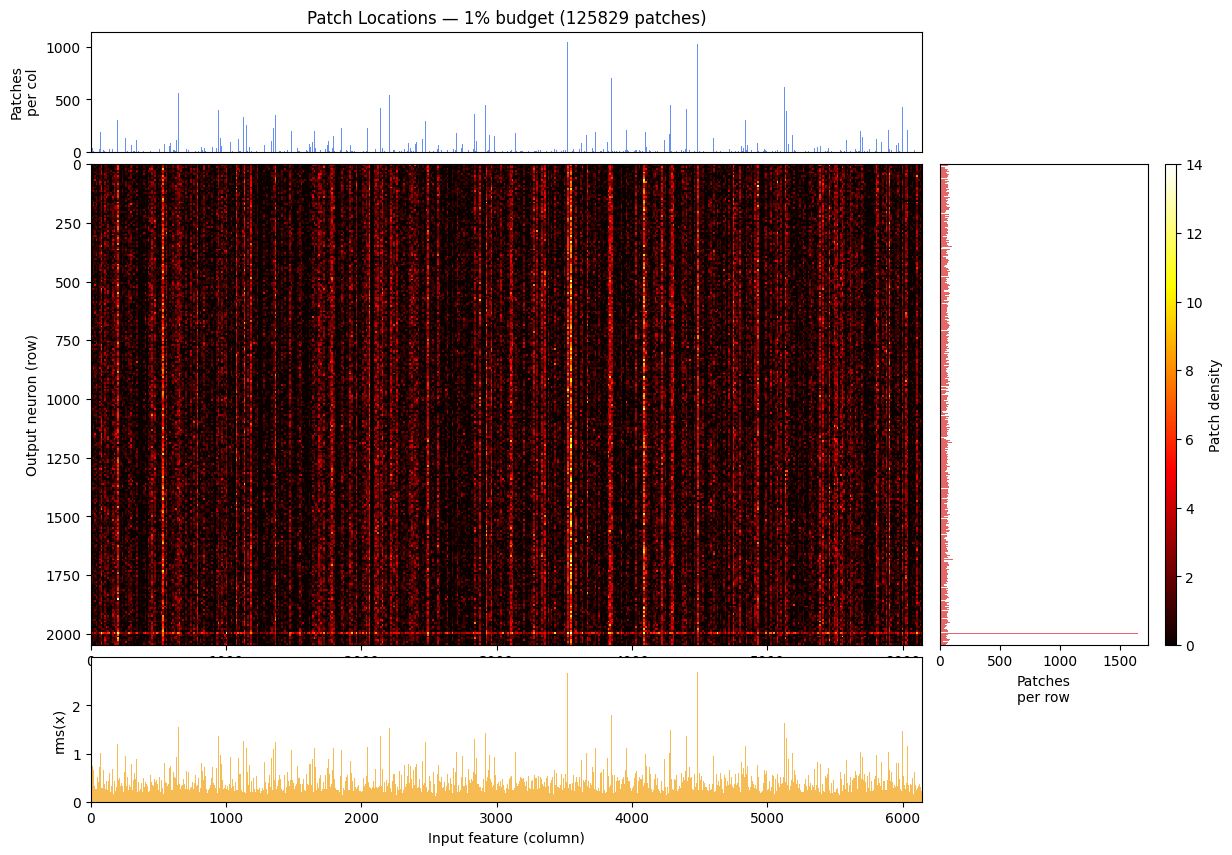


Patch residuals:
  Mean: 0.000103,  Std: 0.041798
  Min: -0.569106,  Max: 0.536606,  Range: 1.105712
  8-bit uniform: RMSE=0.001251  scale=0.004336  entropy=4.71 bits
  6-bit uniform: RMSE=0.005062  scale=0.017551  entropy=2.80 bits
  4-bit uniform: RMSE=0.019657  scale=0.073714  entropy=1.29 bits


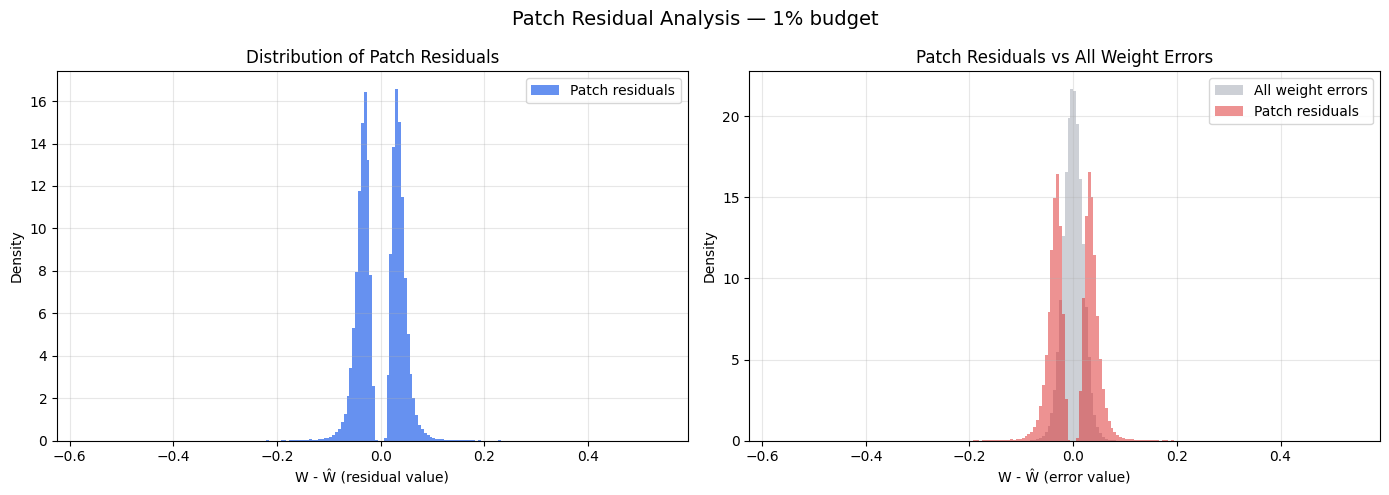

In [ ]:
PATCH_BUDGET = 0.01

act_data = torch.load(ACTIVATIONS_PATH, weights_only=False)
cb_data = torch.load(CODEBOOK_PATH, weights_only=False)

X = act_data["activations"]; W = act_data["weight"]; W_hat = cb_data["W_hat"]
metadata = act_data["metadata"]
out_features, in_features = W.shape
num_weights = out_features * in_features
num_patches = int(num_weights * PATCH_BUDGET)
num_groups_per_row = in_features // CODE_SIZE
num_groups_total = out_features * num_groups_per_row

# Saliency and selection
diff = (W - W_hat).abs(); rms_x = X.pow(2).mean(dim=0).sqrt()
S = diff * rms_x.unsqueeze(0)
_, topk_flat = torch.topk(S.flatten(), num_patches)
rows = topk_flat // in_features; cols = topk_flat % in_features

# Patch mask
patch_mask = torch.zeros(out_features, in_features)
patch_mask[rows, cols] = 1.0
col_counts = patch_mask.sum(dim=0).numpy()
row_counts = patch_mask.sum(dim=1).numpy()

# Group coverage
group_mask = patch_mask.reshape(out_features, num_groups_per_row, CODE_SIZE)
group_has_patch = (group_mask.sum(dim=2) > 0).float()
groups_with_patches = int(group_has_patch.sum().item())

print(f"Group coverage:")
print(f"  Total groups:         {num_groups_total}")
print(f"  Groups with ≥1 patch: {groups_with_patches} ({groups_with_patches / num_groups_total * 100:.2f}%)")
print(f"  Avg patches/group:    {num_patches / max(groups_with_patches, 1):.2f}")

rms_x_np = rms_x.numpy()
corr = np.corrcoef(col_counts, rms_x_np)[0, 1]
print(f"  Correlation(col_patch_count, rms_x): {corr:.4f}")

# Heatmap plot
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(3, 3, height_ratios=[1, 4, 1.2], width_ratios=[4, 1, 0.05], hspace=0.05, wspace=0.05)

ax_col = fig.add_subplot(gs[0, 0])
ax_col.bar(np.arange(in_features), col_counts, width=1.0, color="#2563eb", alpha=0.7)
ax_col.set_xlim(0, in_features); ax_col.set_ylabel("Patches\nper col"); ax_col.set_xticks([])
ax_col.set_title(f"Patch Locations — {PATCH_BUDGET*100:.0f}% budget ({num_patches} patches)")

ax_main = fig.add_subplot(gs[1, 0])
bin_rows = max(1, out_features // 256); bin_cols = max(1, in_features // 512)
heatmap = patch_mask.reshape(out_features // bin_rows, bin_rows, in_features // bin_cols, bin_cols).sum(dim=(1, 3)).numpy()
im = ax_main.imshow(heatmap, aspect="auto", cmap="hot", interpolation="nearest", extent=[0, in_features, out_features, 0])
ax_main.set_xlabel("Input feature (column)"); ax_main.set_ylabel("Output neuron (row)")

ax_row = fig.add_subplot(gs[1, 1])
ax_row.barh(np.arange(out_features), row_counts, height=1.0, color="#dc2626", alpha=0.7)
ax_row.set_ylim(out_features, 0); ax_row.set_xlabel("Patches\nper row"); ax_row.set_yticks([])

ax_cb = fig.add_subplot(gs[1, 2]); fig.colorbar(im, cax=ax_cb, label="Patch density")

ax_rms = fig.add_subplot(gs[2, 0])
ax_rms.bar(np.arange(in_features), rms_x_np, width=1.0, color="#f59e0b", alpha=0.7)
ax_rms.set_xlim(0, in_features); ax_rms.set_xlabel("Input feature (column)"); ax_rms.set_ylabel("rms(x)")
fig.tight_layout(); plt.show()

# Residual analysis
residuals = (W[rows, cols] - W_hat[rows, cols]).numpy()
all_errors = (W - W_hat).numpy().flatten()

print(f"\nPatch residuals:")
print(f"  Mean: {residuals.mean():.6f},  Std: {residuals.std():.6f}")
print(f"  Min: {residuals.min():.6f},  Max: {residuals.max():.6f},  Range: {residuals.max() - residuals.min():.6f}")

for bits in [8, 6, 4]:
    levels = 2 ** bits
    scale = (residuals.max() - residuals.min()) / (levels - 1)
    quantized = np.round((residuals - residuals.min()) / scale) * scale + residuals.min()
    quant_error = np.sqrt(np.mean((residuals - quantized) ** 2))
    bin_indices = np.clip(np.round((residuals - residuals.min()) / scale).astype(int), 0, levels - 1)
    counts = np.bincount(bin_indices, minlength=levels)
    probs = counts[counts > 0] / counts.sum()
    entropy = -np.sum(probs * np.log2(probs))
    print(f"  {bits}-bit uniform: RMSE={quant_error:.6f}  scale={scale:.6f}  entropy={entropy:.2f} bits")

fig2, (ax_hist, ax_comp) = plt.subplots(1, 2, figsize=(14, 5))
ax_hist.hist(residuals, bins=200, color="#2563eb", alpha=0.7, density=True, label="Patch residuals")
ax_hist.set_xlabel("W - Ŵ (residual value)"); ax_hist.set_ylabel("Density")
ax_hist.set_title("Distribution of Patch Residuals"); ax_hist.legend(); ax_hist.grid(True, alpha=0.3)

ax_comp.hist(all_errors, bins=200, color="#9ca3af", alpha=0.5, density=True, label="All weight errors")
ax_comp.hist(residuals, bins=200, color="#dc2626", alpha=0.5, density=True, label="Patch residuals")
ax_comp.set_xlabel("W - Ŵ (error value)"); ax_comp.set_ylabel("Density")
ax_comp.set_title("Patch Residuals vs All Weight Errors"); ax_comp.legend(); ax_comp.grid(True, alpha=0.3)
fig2.suptitle(f"Patch Residual Analysis — {PATCH_BUDGET*100:.0f}% budget", fontsize=14)
fig2.tight_layout(); plt.show()
